# 随机森林（Random Forest）原理解析与实战


---

## 模块一：随机森林核心原理

### 1.1 为什么需要集成学习？

单棵决策树容易过拟合，方差（Variance）很高。

集成学习的目标：**通过组合多个弱学习器，降低整体方差，同时保持低偏差**。

### 1.2 随机森林 = Bagging + 随机特征子空间

#### 核心公式：

一个有 $ T $ 棵树的随机森林预测函数为：

$$
\boxed{
\begin{cases}
\text{分类：}\quad \hat{y} = \text{mode}\{h_1(\mathbf{x}), h_2(\mathbf{x}), \dots, h_T(\mathbf{x})\} \\\\
\text{回归：}\quad \hat{y} = \frac{1}{T}\sum_{t=1}^T h_t(\mathbf{x})
\end{cases}}
$$

其中 $ h_t(\mathbf{x}) $ 是第 $ t $ 棵决策树。

#### Bagging（Bootstrap Aggregating）的数学本质：

从原始数据集 $ D $（大小 $ N $）中有放回抽样 $ T $ 次，得到 $ T $ 个子数据集 $ D_1, D_2, \dots, D_T $，每个大小仍为 $ N $。

每个样本未被抽中的概率：
$$
\left(1 - \frac{1}{N}\right)^N \to \frac{1}{e} \approx 0.368
$$
即约 **36.8%** 的样本成为 **袋外数据（OOB）**，可用于无偏估计。

#### 随机特征选择（去相关）：

在每个节点分裂时，不考虑全部 $ p $ 个特征，而是随机抽取 $ m_{try} $ 个特征，再选最优分裂。

常用经验规则：
- 分类：$ m_{try} = \sqrt{p} $
- 回归：$ m_{try} = p/3 $

数学上证明：随机特征选择大幅降低树之间的相关性 $ \rho $，从而降低集成方差：
$$
\text{Var}_{\text{rf}} \approx \rho \cdot \text{Var}_{\text{single}} + (1-\rho)\cdot \frac{\text{Var}_{\text{single}}}{T}
$$
当 $ \rho \to 0 $ 时，方差接近 $ \text{Var}/T $。

### 1.3 特征重要性（Gini Importance）

第 $ j $ 个特征的重要性 = 所有树在所有节点使用该特征时减少的 Gini 不纯度的加权平均。

节点 $ t $ 的 Gini 不纯度：
$$
Gini(t) = 1 - \sum_{k=1}^K p_k^2
$$

特征 $ j $ 在单棵树中的重要性：
$$
\text{Imp}_j = \sum_{\text{node uses } j} p(t) \cdot \Delta Gini(t)
$$

随机森林取 $ T $ 棵树的平均。

---

## 模块二：分类任务实战（乳腺癌数据集）

In [1]:
# 模块二：分类任务实战
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 中文支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

print(f"样本数: {X.shape[0]}, 特征数: {X.shape[1]}")
print(f"良性/恶性比例: {np.bincount(y)}")
X.head()

样本数: 569, 特征数: 30
良性/恶性比例: [212 357]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 数据划分与模型训练

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 创建随机森林（推荐参数）
rf_clf = RandomForestClassifier(
    n_estimators=1000,        # 树越多越稳定
    max_features='sqrt',      # 分类任务经典选择
    bootstrap=True,           # 开启Bagging
    oob_score=True,           # 计算OOB得分
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)

# OOB 得分（无需验证集的无偏估计）
print(f"OOB Accuracy: {rf_clf.oob_score_:.4f}")

# 测试集表现
y_pred = rf_clf.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n分类报告：")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

OOB Accuracy: 0.9604
Test Accuracy: 0.9561

分类报告：
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### 特征重要性可视化

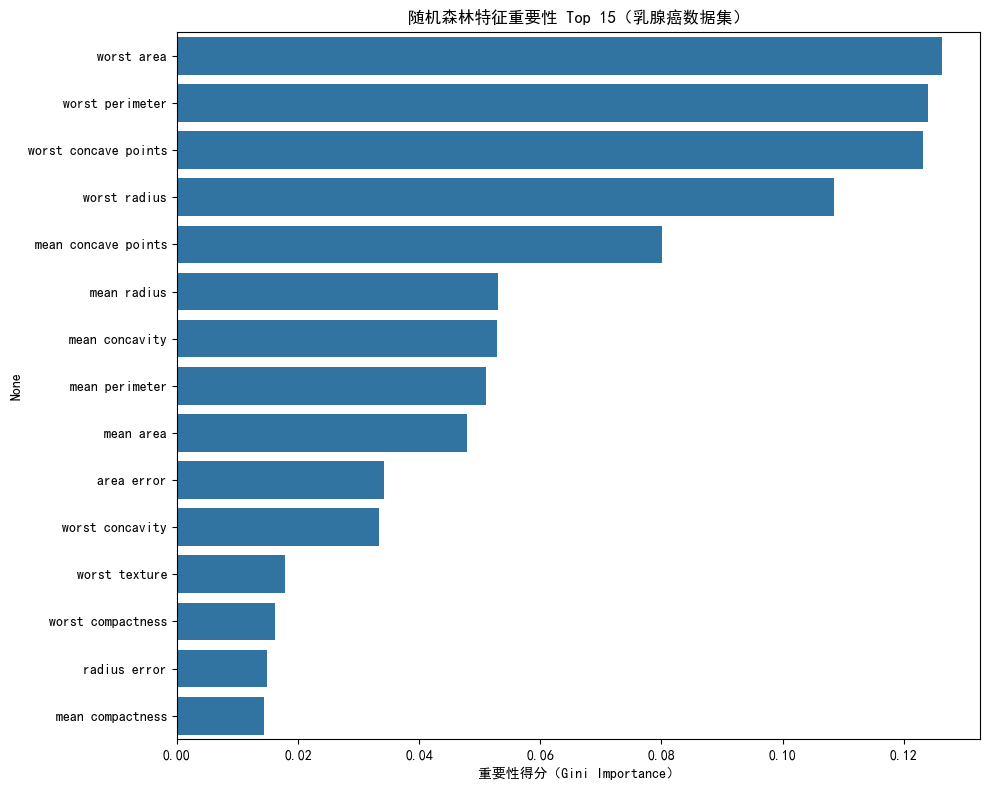

In [3]:
importances = rf_clf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=feat_imp[:15], y=feat_imp.index[:15])
plt.title("随机森林特征重要性 Top 15（乳腺癌数据集）")
plt.xlabel("重要性得分（Gini Importance）")
plt.tight_layout()
plt.show()

## 模块三：回归任务实战（加州房价数据集）

In [4]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing()
X_reg = pd.DataFrame(housing.data, columns=housing.feature_names)
y_reg = housing.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(
    n_estimators=1000,
    max_features='sqrt',      # 回归常用 1/3，此处用 sqrt 也很好
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train_r, y_train_r)

pred = rf_reg.predict(X_test_r)
# 兼容所有版本的最简写法
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_r, pred)):.4f}")
print(f"R²: {r2_score(y_test_r, pred):.4f}")
print(f"OOB R²: {rf_reg.oob_score_:.4f}")

RMSE: 0.4913
R²: 0.8158
OOB R²: 0.8224


### 回归特征重要性

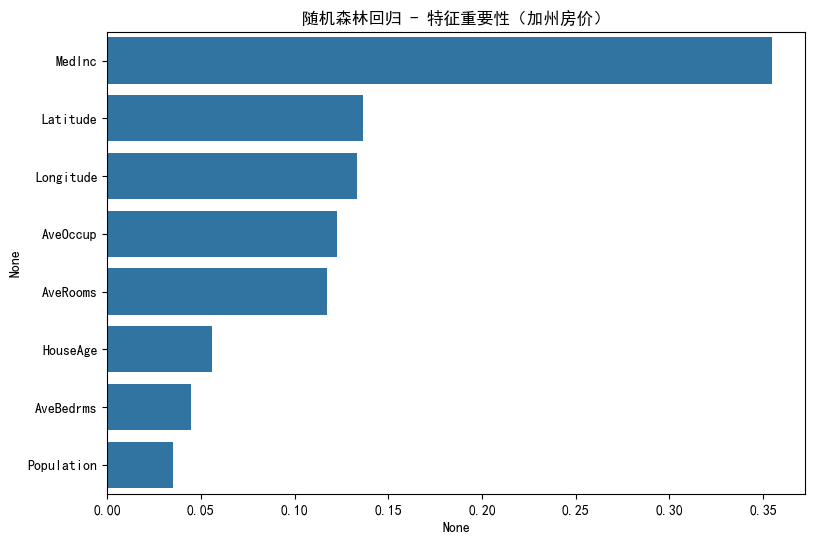

In [5]:
imp_reg = pd.Series(rf_reg.feature_importances_, index=X_reg.columns).sort_values(ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(x=imp_reg, y=imp_reg.index)
plt.title("随机森林回归 - 特征重要性（加州房价）")
plt.show()

## 模块四：超参数调优（GridSearchCV + RandomizedSearchCV）

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# 只要跑 30~50 次组合就足以找到接近最优的参数
param_dist = {
    'n_estimators': randint(300, 1200),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None, 0.2, 0.3, 0.4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist,
    n_iter=40,           # 只试40组参数（原来324组 → 40组，速度提升8倍）
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("最佳参数:", random_search.best_params_)
print("最佳CV准确率:", random_search.best_score_)
print("测试集准确率:", random_search.score(X_test, y_test))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
最佳参数: {'max_depth': 20, 'max_features': 0.4, 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 643}
最佳CV准确率: 0.9604395604395606
测试集准确率: 0.956140350877193


## 模块五：总结与最佳实践

| 项目                  | 推荐设置                              |
|-----------------------|---------------------------------------|
| n_estimators          | ≥500（越多越好，视算力而定）           |
| max_features          | 分类：'sqrt'；回归：'sqrt' 或 1/3     |
| bootstrap             | True（必须开启 Bagging）               |
| oob_score             | True（免费得到泛化误差估计）            |
| n_jobs                | -1（全核心并行）                       |
| 首选场景              | 表格数据、特征重要性、快速建模         |
